# Frontiers of parameters vs approximation performance

This notebook will measure how well different structured matrix parameterizations perform in approximating SAE encoder and decoder weight matrices. We will visualize this in a 2D plot where one axis is the number of parameters in the structured parameterization over the number of parameters in the original weight matrix and the other axis is the approximation error (mean across all entries in the matrix).

In [1]:
import os
from collections import defaultdict
import pickle

import numpy as np

import torch
import blobfile as bf
import transformer_lens
from huggingface_hub import hf_hub_download
# from sae_lens import SparseAutoencoderDictionary
import sparse_autoencoder

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from structured_sae.operations import (
    low_rank_mmm,
    kronecker_mmm,
    sum_kronecker_mmm,
)

In [2]:
!nvidia-smi

Sun Aug 11 15:53:36 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:C4:00.0 Off |                    0 |
| N/A   38C    P0             73W /  300W |    5239MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# compute prime factorization
def prime_factors(n):
    """Returns list of prime factors of n.
    >>> prime_factors(10)
    [2, 5]
    >>> prime_factors(32)
    [2, 2, 2, 2, 2]
    """
    i = 2
    factors = []
    while i * i <= n:
        if n % i:
            i += 1
        else:
            n //= i
            factors.append(i)
    if n > 1:
        factors.append(n)
    return factors

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.set_default_dtype(dtype)

In [5]:
layer_index = 7
location = "resid_post_mlp"

In [6]:
with bf.BlobFile(sparse_autoencoder.paths.v5_32k(location, layer_index), mode="rb") as f:
    state_dict = torch.load(f)
    autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
    autoencoder.to(device)

In [7]:
W_e = autoencoder.encoder.weight.detach()
W_d = autoencoder.decoder.weight.detach()

In [8]:
for i, d in enumerate(W_e.shape):
    print(f"W_e dim {i} size {d:7d}:  {prime_factors(d)}")
for i, d in enumerate(W_d.shape):
    print(f"W_d dim {i} size {d:7d}:  {prime_factors(d)}")

W_e dim 0 size   32768:  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
W_e dim 1 size     768:  [2, 2, 2, 2, 2, 2, 2, 2, 3]
W_d dim 0 size     768:  [2, 2, 2, 2, 2, 2, 2, 2, 3]
W_d dim 1 size   32768:  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


### Low rank approximation

In [45]:
low_rank_encoder_dynamics = defaultdict(list)
low_rank_encoder_parameters = dict()

steps = 3_000
ranks = [8, 16, 32, 64, 128, 192, 256, 384, 512, 640, 768, 896, 1024]

print("Approximating encoder matrix")
for r in tqdm(ranks):
    var_W_e = W_e.var().item()

    W1 = torch.randn(W_e.shape[0], r, device=device, dtype=dtype)
    W2 = torch.randn(r, W_e.shape[1], device=device, dtype=dtype)

    # set the variances appropriately
    # W_ij = W1_ik W2_kj, so sum across columns of W1 and rows of W2
    # each is a sum of r variables, so variance is r times the variance
    # of each term. each term is a product of two Gaussians with variance
    # s^2. So var_W_e = r * (s^2 * s^2) = r * s^4. So s = (var_W_e / r)^(1/4)
    s = (var_W_e / r) ** 0.25
    W1 *= s
    W2 *= s
    W1.requires_grad = True
    W2.requires_grad = True

    low_rank_encoder_parameters[r] = W1.numel() + W2.numel()

    # gradient descent to optimize W1, W2
    optimizer = torch.optim.Adam([W1, W2], lr=1e-3)
    for i in range(steps):
        W_e_approx = W1 @ W2
        loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        low_rank_encoder_dynamics[r].append(loss.item())


Approximating encoder matrix


  0%|          | 0/13 [00:00<?, ?it/s]

In [49]:
# save the data
os.makedirs("../saved_data", exist_ok=True)
with open(f"saved_data/layer{layer_index}_{location}_v5_32k_encoder_low_rank_dynamics.pkl", "wb") as f:
    pickle.dump(low_rank_encoder_dynamics, f)

with open(f"../saved_data/layer{layer_index}_{location}_v5_32k_encoder_low_rank_parameters.pkl", "wb") as f: 
    pickle.dump(low_rank_encoder_parameters, f)

In [9]:
steps = 3_000
ranks = [8, 16, 32, 64, 128, 192, 256, 384, 512, 640, 768, 896, 1024]

# load the data
with open(f"../saved_data/layer{layer_index}_{location}_v5_32k_encoder_low_rank_dynamics.pkl", "rb") as f:
    low_rank_encoder_dynamics = pickle.load(f)

with open(f"../saved_data/layer{layer_index}_{location}_v5_32k_encoder_low_rank_parameters.pkl", "rb") as f:
    low_rank_encoder_parameters = pickle.load(f)

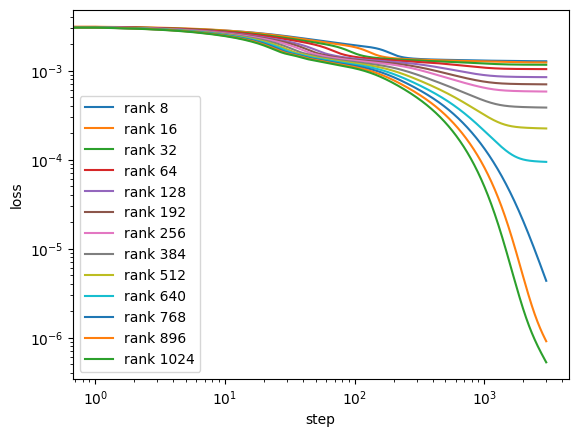

In [10]:
for r in ranks:
    plt.plot(list(range(len(low_rank_encoder_dynamics[8]))), low_rank_encoder_dynamics[r], label=f"rank {r}")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('step')
plt.ylabel('loss')
plt.legend()

Text(0.5, 1.0, 'Low rank approximation of W_e')

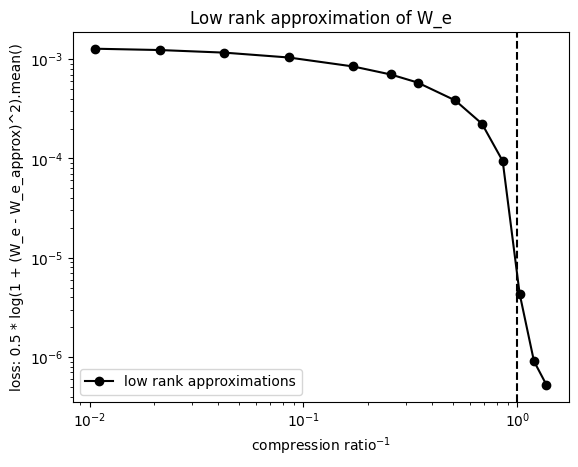

In [15]:
# plot frontier
ratios = [low_rank_encoder_parameters[r] / W_e.numel() for r in ranks]
losses = [min(low_rank_encoder_dynamics[r]) for r in ranks]

plt.plot(ratios, losses, 'o-', label='low rank approximations', color='black')
# vertical line at ratio = 1
plt.axvline(x=1, color='k', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\text{compression ratio}^{-1}$')
plt.ylabel('loss: 0.5 * log(1 + (W_e - W_e_approx)^2).mean()')
plt.legend()
plt.title("Low rank approximation of W_e")

### Compare with SVD performance

In [12]:
# compute SVD of W_e
U, S, V = torch.linalg.svd(W_e, full_matrices=False)
svd_ranks = list(range(4, 768, 4))

# compute loss on various ranks of the SVD
svd_losses = []
svd_parameters = []
for rank in tqdm(svd_ranks):
    U_r = U[:, :rank]
    S_r = S[:rank]
    V_r = V[:rank, :]
    W_e_approx = U_r @ torch.diag(S_r) @ V_r
    loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
    svd_losses.append(loss.item())
    svd_parameters.append(U_r.numel() + S_r.numel() + V_r.numel())

  0%|          | 0/191 [00:00<?, ?it/s]

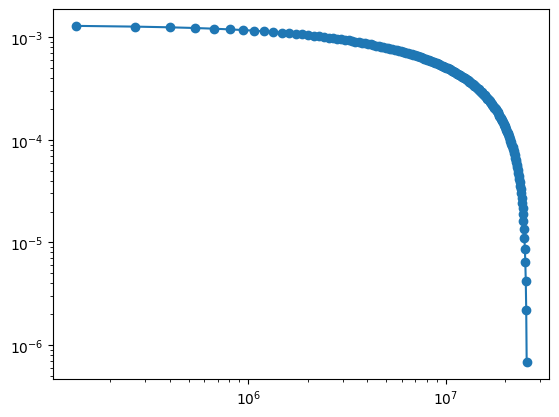

In [13]:
plt.plot(svd_parameters, svd_losses, 'o-')
plt.yscale('log')
plt.xscale('log')

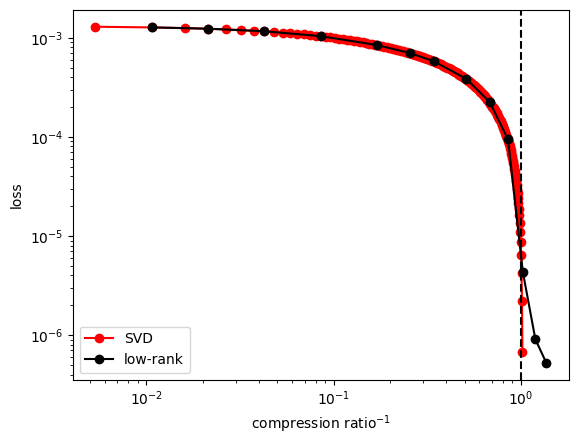

In [14]:
# plot both the low-rank and svd results

svd_ratios = [p / W_e.numel() for p in svd_parameters]
plt.plot(svd_ratios, svd_losses, 'o-', label='SVD', color='red')
plt.plot(ratios, losses, 'o-', label='low-rank', color='black')
plt.axvline(x=1, color='k', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\text{compression ratio}^{-1}$')
plt.ylabel('loss')
plt.legend()

Text(0.5, 1.0, 'Sum-Kronecker-Product vs. Low-Rank Approximations of W_e')

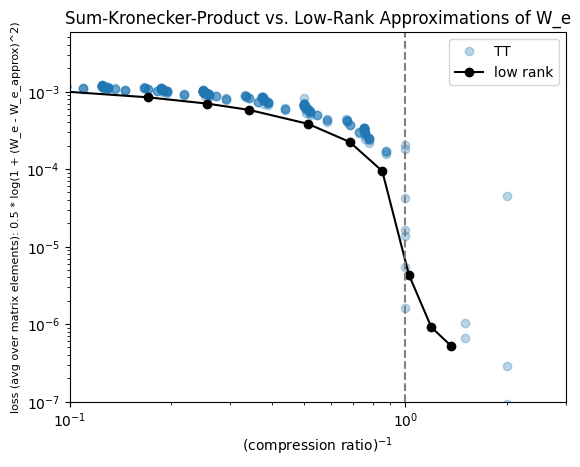

In [20]:
# visualize both the original and rightmult results
import re

i = 0
# iterate through ../saved_data directory
for file in os.listdir("../saved_data"):
    pattern = r'layer7_resid_post_mlp_v5_32k_encoder_sum_kronecker_\d+x\d+_\d+x\d+_results\.pkl$'
    if re.match(pattern, file):
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o', color='C0', alpha=0.3, label="TT" if i == 0 else None) # label=f"{d1}x{d2} {d3}x{d4}")
                i += 1
            except:
                pass

# for file in os.listdir("../saved_data"):
#     pattern = r'layer7_resid_post_mlp_v5_32k_encoder_sum_kronecker_\d+x\d+_\d+x\d+_rightmult_results\.pkl$'
#     if re.match(pattern, file):
#         with open(f"../saved_data/{file}", "rb") as f:
#             data = pickle.load(f)
#             try:
#                 d1 = data['d1']
#                 d2 = data['d2']
#                 d3 = data['d3']
#                 d4 = data['d4']
#                 rs = sorted(data['losses'].keys())
#                 parameters = [data['parameters'][r] for r in rs]
#                 ratios = [p / W_e.numel() for p in parameters]
#                 losses = [min(data['losses'][r]) for r in rs]
#                 plt.plot(ratios, losses, 'o', color='C1') # label=f"{d1}x{d2} {d3}x{d4}")
#             except:
#                 pass

# plot the low-rank frontier too
low_rank_ratios = [low_rank_encoder_parameters[r] / W_e.numel() for r in ranks]
low_rank_losses = [min(low_rank_encoder_dynamics[r]) for r in ranks]
plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank', color='black')

# vertical line
plt.axvline(x=1, color='grey', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-7, None)
plt.xlim(1e-1, 3e0)
plt.xlabel(r"$(\text{compression ratio})^{-1}$")
plt.ylabel("loss (avg over matrix elements): 0.5 * log(1 + (W_e - W_e_approx)^2)", fontsize=8)
plt.legend()
plt.title("Sum-Kronecker-Product vs. Low-Rank Approximations of W_e")

Text(0.5, 1.0, 'TT * V vs. Low-Rank Approximations of W_e')

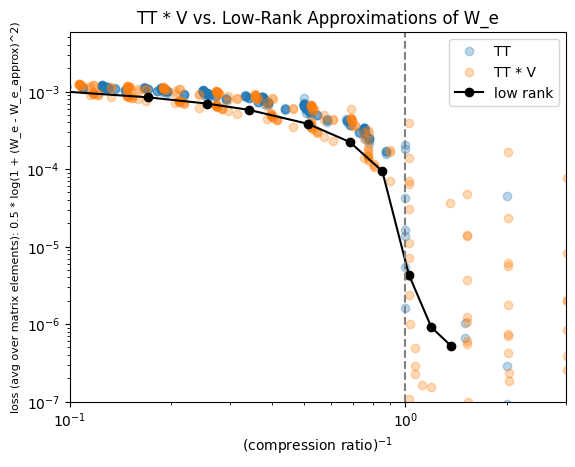

In [22]:
# visualize both the original and rightmult results
import re

i = 0
# iterate through ../saved_data directory
for file in os.listdir("../saved_data"):
    pattern = r'layer7_resid_post_mlp_v5_32k_encoder_sum_kronecker_\d+x\d+_\d+x\d+_results\.pkl$'
    if re.match(pattern, file):
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o', color='C0', alpha=0.3, label="TT" if i == 0 else None) # label=f"{d1}x{d2} {d3}x{d4}")
                i += 1
            except:
                pass

i = 0
for file in os.listdir("../saved_data"):
    pattern = r'layer7_resid_post_mlp_v5_32k_encoder_sum_kronecker_\d+x\d+_\d+x\d+_rightmult_results\.pkl$'
    if re.match(pattern, file):
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o', color='C1', alpha=0.3, label="TT * V" if i == 0 else None) # label=f"{d1}x{d2} {d3}x{d4}")
                i += 1
            except:
                pass

# plot the low-rank frontier too
low_rank_ratios = [low_rank_encoder_parameters[r] / W_e.numel() for r in ranks]
low_rank_losses = [min(low_rank_encoder_dynamics[r]) for r in ranks]
plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank', color='black')

# vertical line
plt.axvline(x=1, color='grey', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-7, None)
plt.xlim(1e-1, 3e0)
plt.xlabel(r"$(\text{compression ratio})^{-1}$")
plt.ylabel("loss (avg over matrix elements): 0.5 * log(1 + (W_e - W_e_approx)^2)", fontsize=8)
plt.legend()
plt.title("TT * V vs. Low-Rank Approximations of W_e")

Text(0.5, 1.0, 'TT * V vs. Low-Rank Approximations of W_e')

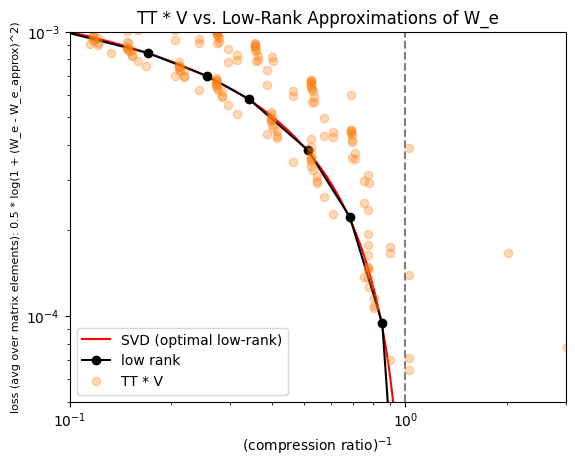

In [25]:
# replot the TT * V with the svd decomposition line and zoom in

plt.plot(svd_ratios, svd_losses, label='SVD (optimal low-rank)', color='red')

# also plot the low-rank frontier
plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank', color='black')

i = 0
for file in os.listdir("../saved_data"):
    pattern = r'layer7_resid_post_mlp_v5_32k_encoder_sum_kronecker_\d+x\d+_\d+x\d+_rightmult_results\.pkl$'
    if re.match(pattern, file):
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o', color='C1', alpha=0.3, label="TT * V" if i == 0 else None) # label=f"{d1}x{d2} {d3}x{d4}")
                i += 1
            except:
                pass

# vertical line
plt.axvline(x=1, color='grey', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.ylim(5e-5, 1e-3)
plt.xlim(1e-1, 3e0)
plt.xlabel(r"$(\text{compression ratio})^{-1}$")
plt.ylabel("loss (avg over matrix elements): 0.5 * log(1 + (W_e - W_e_approx)^2)", fontsize=8)
plt.legend()
plt.title("TT * V vs. Low-Rank Approximations of W_e")

In [24]:
U, S, V = torch.linalg.svd(W_e, full_matrices=False)

In [28]:
(U @ torch.diag(S) @ V - W_e).square().mean().item()

1.3241722995882554e-10

In [30]:
U.shape

torch.Size([32768, 768])

### Sum of Kronecker products

In [68]:
rs = [8, 16, 32, 64, 128, 192, 256, 384, 512, 640, 768, 896, 1024]
sum_kronecker_32x32_1024x24_encoder_dynamics = defaultdict(list)
sum_kronecker_32x32_1024x24_encoder_parameters = dict()
steps = 5_000

for r in tqdm(rs):
    d1, d2 = 32, 32
    d3, d4 = 1024, 24
    assert d1 * d3 == W_e.shape[0]
    assert d2 * d4 == W_e.shape[1]
    W1 = torch.randn(r, d1, d2, device=device, dtype=dtype)
    W2 = torch.randn(r, d3, d4, device=device, dtype=dtype)

    # we want the variance of sum_kronecker_mmm(W1, W2) to be the same as the variance of W_e
    # this matrix will be a sum of r products. what is the variance of each element in 
    # each product? since each element in a Kronecker product is a product of two elements,
    # it will just be the product of the variances of the two elements. Let s
    # be the standard deviation of element in W1 and W2. Then the variance of the product
    # will be s^2 * s^2 = s^4. So the variance of the sum of r products will be r * s^4.
    # so s = (var_W_e / r)^(1/4)
    s = (var_W_e / r) ** 0.25
    W1 *= s
    W2 *= s
    W1.requires_grad = True
    W2.requires_grad = True

    sum_kronecker_32x32_1024x24_encoder_parameters[r] = W1.numel() + W2.numel()

    optimizer = torch.optim.Adam([W1, W2], lr=1e-3)
    for i in range(steps):
        W_e_approx = sum_kronecker_mmm(W1, W2)
        loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        sum_kronecker_32x32_1024x24_encoder_dynamics[r].append(loss.item())

  0%|          | 0/13 [00:00<?, ?it/s]

In [69]:
# save
with open(f"saved_data/layer{layer_index}_{location}_v5_32k_encoder_sum_kronecker_32x32_1024x24_dynamics.pkl", "wb") as f:
    pickle.dump(sum_kronecker_32x32_1024x24_encoder_dynamics, f)

with open(f"saved_data/layer{layer_index}_{location}_v5_32k_encoder_sum_kronecker_32x32_1024x24_parameters.pkl", "wb") as f:
    pickle.dump(sum_kronecker_32x32_1024x24_encoder_parameters, f)

In [70]:
# load
with open(f"saved_data/layer{layer_index}_{location}_v5_32k_encoder_sum_kronecker_32x32_1024x24_dynamics.pkl", "rb") as f:
    sum_kronecker_32x32_1024x24_encoder_dynamics = pickle.load(f)

with open(f"saved_data/layer{layer_index}_{location}_v5_32k_encoder_sum_kronecker_32x32_1024x24_parameters.pkl", "rb") as f:
    sum_kronecker_32x32_1024x24_encoder_parameters = pickle.load(f)

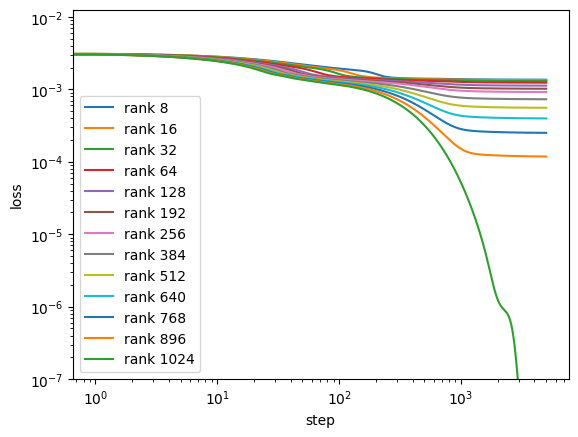

In [71]:
for r in rs:
    plt.plot(list(range(len(sum_kronecker_32x32_1024x24_encoder_dynamics[r]))), sum_kronecker_32x32_1024x24_encoder_dynamics[r], label=f"rank {r}")
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-7, None)
plt.xlabel('step')
plt.ylabel('loss')
plt.legend()

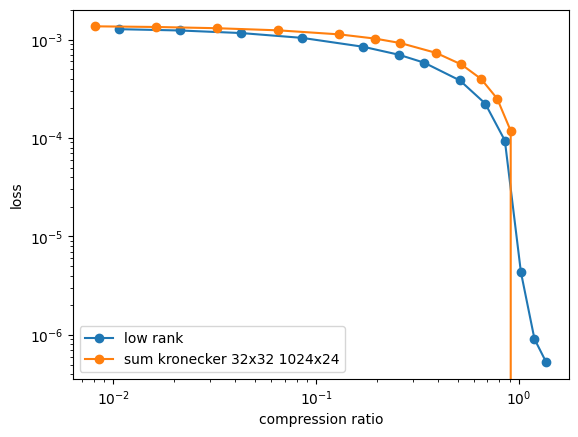

In [73]:
# plot the frontier for both the low rank and sum_kronecker methods

low_rank_ratios = [low_rank_encoder_parameters[r] / W_e.numel() for r in ranks]
low_rank_losses = [min(low_rank_encoder_dynamics[r]) for r in ranks]

sum_kronecker_ratios = [sum_kronecker_32x32_1024x24_encoder_parameters[r] / W_e.numel() for r in rs]
sum_kronecker_losses = [min(sum_kronecker_32x32_1024x24_encoder_dynamics[r]) for r in rs]

plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank')
plt.plot(sum_kronecker_ratios, sum_kronecker_losses, 'o-', label='sum kronecker 32x32 1024x24')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('compression ratio')
plt.ylabel('loss')
plt.legend()

### Plot frontiers for many different shapes of sum_kronecker

Text(0.5, 1.0, 'Sum-Kronecker-Product vs. Low-Rank Approximations of W_e')

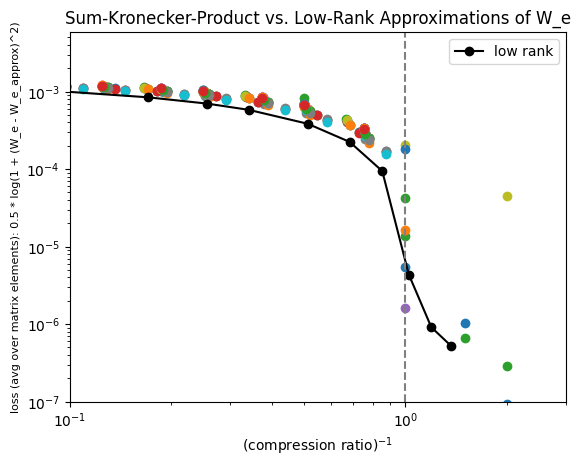

In [59]:
# iterate through ../saved_data directory
for file in os.listdir("../saved_data"):
    if file.startswith(f"layer{layer_index}_{location}_v5_32k_encoder_sum_kronecker_") and file.endswith(".pkl"):
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o') # label=f"{d1}x{d2} {d3}x{d4}")
            except:
                pass

# plot the low-rank frontier too
low_rank_ratios = [low_rank_encoder_parameters[r] / W_e.numel() for r in ranks]
low_rank_losses = [min(low_rank_encoder_dynamics[r]) for r in ranks]
plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank', color='black')

# vertical line
plt.axvline(x=1, color='grey', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-7, None)
plt.xlim(1e-1, 3e0)
plt.xlabel(r"$(\text{compression ratio})^{-1}$")
plt.ylabel("loss (avg over matrix elements): 0.5 * log(1 + (W_e - W_e_approx)^2)", fontsize=8)
plt.legend()
plt.title("Sum-Kronecker-Product vs. Low-Rank Approximations of W_e")

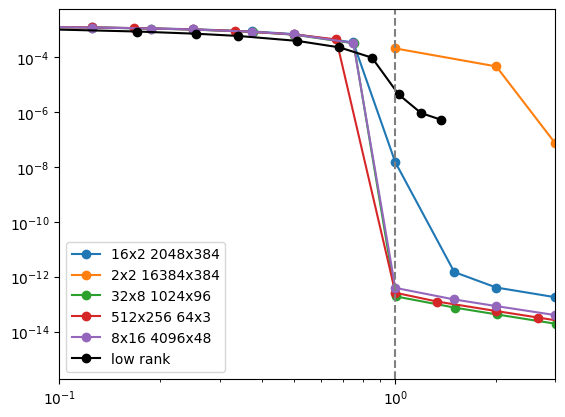

In [47]:
# special candidates
# 16x2 2048x384
# 2x2 16384x384
# 32x8 1024x96
# 512x256 64x3
# 8x16 4096x48

candidates = [
    (16, 2, 2048, 384),
    (2, 2, 16384, 384),
    (32, 8, 1024, 96),
    (512, 256, 64, 3),
    (8, 16, 4096, 48),
]

candidate_filenames = [
    f"layer{layer_index}_{location}_v5_32k_encoder_sum_kronecker_{d1}x{d2}_{d3}x{d4}_results.pkl"
    for d1, d2, d3, d4 in candidates
]

# iterate through ../saved_data directory
for file in os.listdir("../saved_data"):
    if file in candidate_filenames:
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o-', label=f"{d1}x{d2} {d3}x{d4}")
            except:
                pass

# plot the low-rank frontier too
low_rank_ratios = [low_rank_encoder_parameters[r] / W_e.numel() for r in ranks]
low_rank_losses = [min(low_rank_encoder_dynamics[r]) for r in ranks]
plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank', color='black')

# vertical line
plt.axvline(x=1, color='grey', linestyle='--')

plt.xscale('log')
plt.yscale('log')
# plt.ylim(1e-7, None)
plt.xlim(1e-1, 3e0)
plt.legend() 

In [48]:
d1, d2, d3, d4 = 512, 256, 64, 3 # one that drops the earliest

with open(f"../saved_data/layer{layer_index}_{location}_v5_32k_encoder_sum_kronecker_{d1}x{d2}_{d3}x{d4}_results.pkl", "rb") as f:
    data = pickle.load(f)
    rs = sorted(data['losses'].keys())
    parameters = [data['parameters'][r] for r in rs]
    ratios = [p / W_e.numel() for p in parameters]
    losses = [min(data['losses'][r]) for r in rs]

### Takeaways so far

While the lines sometimes drop before the low-rank approximation, there are never any points that are a pareto-improvement on the low-rank approximation.

In [61]:
W_e.abs().mean()

tensor(0.0457, device='cuda:0')

In [62]:
1e-3 ** 0.5

0.03162277660168379

In [13]:
# try the Shampoo optimizer
import torch_optimizer as optim 

In [14]:
(W_e.numel() / (512 * 256 + 64 * 3))

191.7191613846904

In [16]:
rs = [32, 128, 192, 256, 384]
sum_kronecker_512x256_64x3_encoder_dynamics = defaultdict(list)
sum_kronecker_512x256_64x3_encoder_parameters = dict()
steps = 5_000

var_W_e = W_e.var().item()

for r in tqdm(rs):
    d1, d2, d3, d4 = 512, 256, 64, 3
    assert d1 * d3 == W_e.shape[0]
    assert d2 * d4 == W_e.shape[1]
    W1 = torch.randn(r, d1, d2, device=device, dtype=dtype)
    W2 = torch.randn(r, d3, d4, device=device, dtype=dtype)

    # we want the variance of sum_kronecker_mmm(W1, W2) to be the same as the variance of W_e
    # this matrix will be a sum of r products. what is the variance of each element in 
    # each product? since each element in a Kronecker product is a product of two elements,
    # it will just be the product of the variances of the two elements. Let s
    # be the standard deviation of element in W1 and W2. Then the variance of the product
    # will be s^2 * s^2 = s^4. So the variance of the sum of r products will be r * s^4.
    # so s = (var_W_e / r)^(1/4)
    s = (var_W_e / r) ** 0.25
    W1 *= s
    W2 *= s
    W1.requires_grad = True
    W2.requires_grad = True

    # sum_kronecker_32x32_1024x24_encoder_parameters[r] = W1.numel() + W2.numel()
    sum_kronecker_512x256_64x3_encoder_parameters[r] = W1.numel() + W2.numel()

    optimizer = torch.optim.Adam([W1, W2], lr=1e-3)
    for i in range(steps):
        W_e_approx = sum_kronecker_mmm(W1, W2)
        loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # sum_kronecker_32x32_1024x24_encoder_dynamics[r].append(loss.item())
        sum_kronecker_512x256_64x3_encoder_dynamics[r].append(loss.item())


  0%|          | 0/5 [00:00<?, ?it/s]

(10.0, 7652.9221171494255)

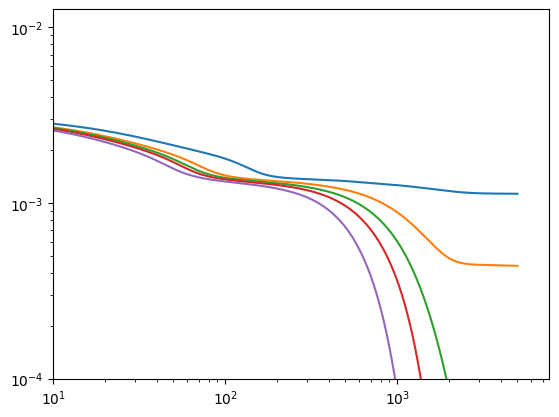

In [22]:
for r in rs:
    plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_encoder_dynamics[r], label=f"rank {r}")
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-4, None)
plt.xlim(1e1, None)
# plt.xscale('log')

In [23]:
# now shampoo

rs = [32, 128, 192, 256, 384]
sum_kronecker_512x256_64x3_encoder_dynamics_shampoo = defaultdict(list)
# sum_kronecker_512x256_64x3_encoder_parameters = dict()
steps = 5_000

var_W_e = W_e.var().item()

for r in tqdm(rs):
    d1, d2, d3, d4 = 512, 256, 64, 3
    assert d1 * d3 == W_e.shape[0]
    assert d2 * d4 == W_e.shape[1]
    W1 = torch.randn(r, d1, d2, device=device, dtype=dtype)
    W2 = torch.randn(r, d3, d4, device=device, dtype=dtype)

    # we want the variance of sum_kronecker_mmm(W1, W2) to be the same as the variance of W_e
    # this matrix will be a sum of r products. what is the variance of each element in 
    # each product? since each element in a Kronecker product is a product of two elements,
    # it will just be the product of the variances of the two elements. Let s
    # be the standard deviation of element in W1 and W2. Then the variance of the product
    # will be s^2 * s^2 = s^4. So the variance of the sum of r products will be r * s^4.
    # so s = (var_W_e / r)^(1/4)
    s = (var_W_e / r) ** 0.25
    W1 *= s
    W2 *= s
    W1.requires_grad = True
    W2.requires_grad = True

    # sum_kronecker_32x32_1024x24_encoder_parameters[r] = W1.numel() + W2.numel()
    # sum_kronecker_512x256_64x3_encoder_parameters[r] = W1.numel() + W2.numel()

    # optimizer = torch.optim.Adam([W1, W2], lr=1e-3)
    optimizer = optim.Shampoo(
        [W1, W2],
        lr=1e-3,
        momentum=0.0,
        weight_decay=0.0,
        epsilon=1e-4,
        update_freq=1,
    )
    for i in range(steps):
        W_e_approx = sum_kronecker_mmm(W1, W2)
        loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # sum_kronecker_32x32_1024x24_encoder_dynamics[r].append(loss.item())
        sum_kronecker_512x256_64x3_encoder_dynamics_shampoo[r].append(loss.item())


  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

It took forever!! Forget shampoo!

### square matrix right-multiplication

In [25]:
rs = [16, 32, 64, 128, 192, 256, 384]
sum_kronecker_512x256_64x3_rightmult_encoder_dynamics = defaultdict(list)
sum_kronecker_512x256_64x3_rightmult_encoder_parameters = dict()
steps = 5_000

var_W_e = W_e.var().item()

for r in tqdm(rs):
    d1, d2, d3, d4 = 512, 256, 64, 3
    assert d1 * d3 == W_e.shape[0]
    assert d2 * d4 == W_e.shape[1]
    W1 = torch.randn(r, d1, d2, device=device, dtype=dtype)
    W2 = torch.randn(r, d3, d4, device=device, dtype=dtype)
    # right-multiplication matrix, initialized to be identity
    U = torch.eye(d2 * d4, device=device, dtype=dtype)

    # we want the variance of sum_kronecker_mmm(W1, W2) to be the same as the variance of W_e
    # this matrix will be a sum of r products. what is the variance of each element in 
    # each product? since each element in a Kronecker product is a product of two elements,
    # it will just be the product of the variances of the two elements. Let s
    # be the standard deviation of element in W1 and W2. Then the variance of the product
    # will be s^2 * s^2 = s^4. So the variance of the sum of r products will be r * s^4.
    # so s = (var_W_e / r)^(1/4)
    s = (var_W_e / r) ** 0.25
    W1 *= s
    W2 *= s
    W1.requires_grad = True
    W2.requires_grad = True
    U.requires_grad = True

    # sum_kronecker_32x32_1024x24_encoder_parameters[r] = W1.numel() + W2.numel()
    sum_kronecker_512x256_64x3_rightmult_encoder_parameters[r] = W1.numel() + W2.numel() + U.numel()

    optimizer = torch.optim.Adam([W1, W2, U], lr=1e-3)
    for i in range(steps):
        W_e_approx = sum_kronecker_mmm(W1, W2) @ U
        loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # sum_kronecker_32x32_1024x24_encoder_dynamics[r].append(loss.item())
        sum_kronecker_512x256_64x3_rightmult_encoder_dynamics[r].append(loss.item())


  0%|          | 0/7 [00:00<?, ?it/s]

(10.0, 7652.9221171494255)

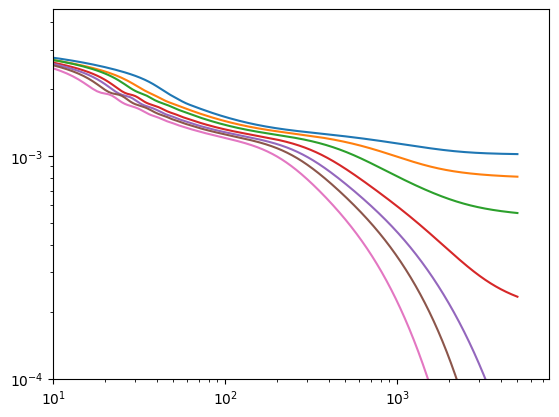

In [26]:
for r in rs:
    plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_rightmult_encoder_dynamics[r], label=f"rank {r}")
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-4, None)
plt.xlim(1e1, None)
# plt.xscale('log')


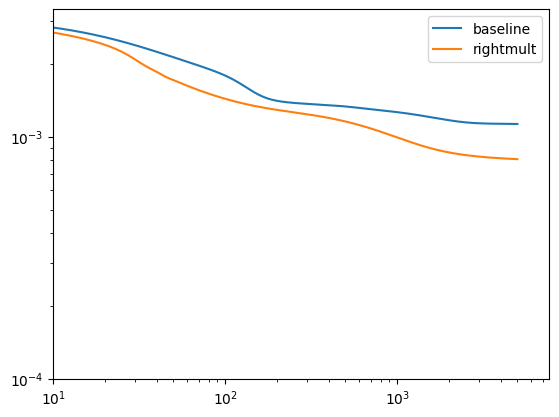

In [28]:
# plot the r=32 for both baseline and rightmult
plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_encoder_dynamics[32], label="baseline")
plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_rightmult_encoder_dynamics[32], label="rightmult")
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-4, None)
plt.xlim(1e1, None)
plt.legend()


In [37]:
# now initialize the right-multiplication matrix to be random
rs = [16, 32, 64, 128, 192, 256, 384]
sum_kronecker_512x256_64x3_rightmult_rand_encoder_dynamics = defaultdict(list)
sum_kronecker_512x256_64x3_rightmult_rand_encoder_parameters = dict()
steps = 5_000

var_W_e = W_e.var().item()

for r in tqdm(rs):
    d1, d2, d3, d4 = 512, 256, 64, 3
    assert d1 * d3 == W_e.shape[0]
    assert d2 * d4 == W_e.shape[1]
    W1 = torch.randn(r, d1, d2, device=device, dtype=dtype)
    W2 = torch.randn(r, d3, d4, device=device, dtype=dtype)
    # right-multiplication matrix, initialized to be identity
    U = torch.randn(d2*d4, d2*d4, device=device, dtype=dtype)

    # we want the variance of sum_kronecker_mmm(W1, W2) to be the same as the variance of W_e
    # this matrix will be a sum of r products. what is the variance of each element in 
    # each product? since each element in a Kronecker product is a product of two elements,
    # it will just be the product of the variances of the two elements. Let s
    # be the standard deviation of element in W1 and W2. Then the variance of the product
    # will be s^2 * s^2 = s^4. So the variance of the sum of r products will be r * s^4.
    # so s = (var_W_e / r)^(1/4)
    s = (var_W_e / r) ** 0.25
    W1 *= s
    W2 *= s
    s_u = (1 / (d2 * d4)) ** 0.5
    U *= s_u
    W1.requires_grad = True
    W2.requires_grad = True
    U.requires_grad = True

    # sum_kronecker_32x32_1024x24_encoder_parameters[r] = W1.numel() + W2.numel()
    sum_kronecker_512x256_64x3_rightmult_rand_encoder_parameters[r] = W1.numel() + W2.numel() + U.numel()

    optimizer = torch.optim.Adam([W1, W2, U], lr=1e-3)
    for i in range(steps):
        W_e_approx = sum_kronecker_mmm(W1, W2) @ U
        loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # sum_kronecker_32x32_1024x24_encoder_dynamics[r].append(loss.item())
        sum_kronecker_512x256_64x3_rightmult_rand_encoder_dynamics[r].append(loss.item())


  0%|          | 0/7 [00:00<?, ?it/s]

(10.0, 7652.9221171494255)

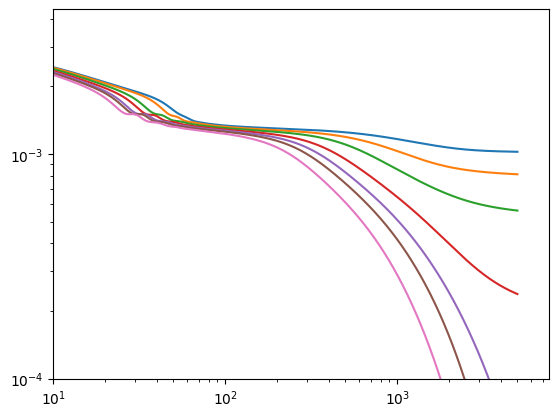

In [38]:
for r in rs:
    plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_rightmult_rand_encoder_dynamics[r], label=f"rank {r}")
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-4, None)
plt.xlim(1e1, None)
# plt.xscale('log')

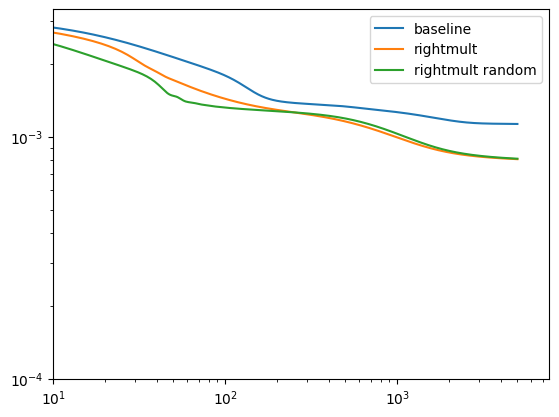

In [39]:
# plot the r=32 for both baseline and rightmult
plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_encoder_dynamics[32], label="baseline")
plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_rightmult_encoder_dynamics[32], label="rightmult")
plt.plot(list(range(steps)), sum_kronecker_512x256_64x3_rightmult_rand_encoder_dynamics[32], label="rightmult random")
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-4, None)
plt.xlim(1e1, None)
plt.legend()


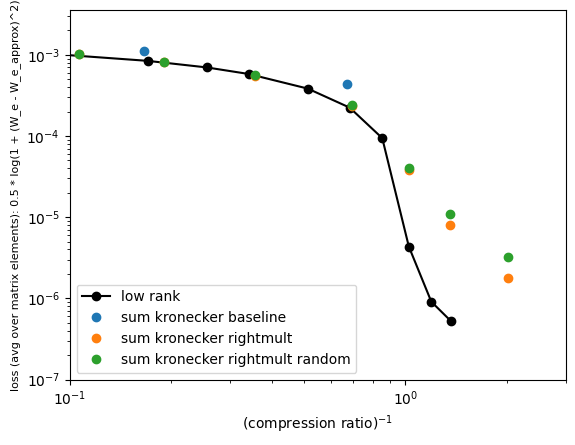

In [43]:
# let's visualize the frontiers for all three of these
# first the baseline low-rank
low_rank_ranks = sorted(low_rank_encoder_dynamics.keys())
low_rank_losses = [min(low_rank_encoder_dynamics[r]) for r in low_rank_ranks]
low_rank_parameters = [low_rank_encoder_parameters[r] for r in low_rank_ranks]
low_rank_ratios = [p / W_e.numel() for p in low_rank_parameters]

# next the sum_kronecker without matrix multiplications
sum_kronecker_ranks = sorted(sum_kronecker_512x256_64x3_encoder_dynamics.keys())
sum_kronecker_losses = [min(sum_kronecker_512x256_64x3_encoder_dynamics[r]) for r in sum_kronecker_ranks]
sum_kronecker_parameters = [sum_kronecker_512x256_64x3_encoder_parameters[r] for r in sum_kronecker_ranks]
sum_kronecker_ratios = [p / W_e.numel() for p in sum_kronecker_parameters]

# next the sum_kronecker with right-multiplications
sum_kronecker_rightmult_ranks = sorted(sum_kronecker_512x256_64x3_rightmult_encoder_dynamics.keys())
sum_kronecker_rightmult_losses = [min(sum_kronecker_512x256_64x3_rightmult_encoder_dynamics[r]) for r in sum_kronecker_rightmult_ranks]
sum_kronecker_rightmult_parameters = [sum_kronecker_512x256_64x3_rightmult_encoder_parameters[r] for r in sum_kronecker_rightmult_ranks]
sum_kronecker_rightmult_ratios = [p / W_e.numel() for p in sum_kronecker_rightmult_parameters]

# next the sum_kronecker with right-multiplications and random initialization
sum_kronecker_rightmult_rand_ranks = sorted(sum_kronecker_512x256_64x3_rightmult_rand_encoder_dynamics.keys())
sum_kronecker_rightmult_rand_losses = [min(sum_kronecker_512x256_64x3_rightmult_rand_encoder_dynamics[r]) for r in sum_kronecker_rightmult_rand_ranks]
sum_kronecker_rightmult_rand_parameters = [sum_kronecker_512x256_64x3_rightmult_rand_encoder_parameters[r] for r in sum_kronecker_rightmult_rand_ranks]
sum_kronecker_rightmult_rand_ratios = [p / W_e.numel() for p in sum_kronecker_rightmult_rand_parameters]

plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank', color='black')
plt.plot(sum_kronecker_ratios, sum_kronecker_losses, 'o', label='sum kronecker baseline')
plt.plot(sum_kronecker_rightmult_ratios, sum_kronecker_rightmult_losses, 'o', label='sum kronecker rightmult')
plt.plot(sum_kronecker_rightmult_rand_ratios, sum_kronecker_rightmult_rand_losses, 'o', label='sum kronecker rightmult random')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-7, None)
plt.xlim(1e-1, 3e0)
plt.xlabel(r"$(\text{compression ratio})^{-1}$")
plt.ylabel("loss (avg over matrix elements): 0.5 * log(1 + (W_e - W_e_approx)^2)", fontsize=8)
plt.legend()

Text(0.5, 1.0, 'Sum-Kronecker-Product vs. Low-Rank Approximations of W_e')

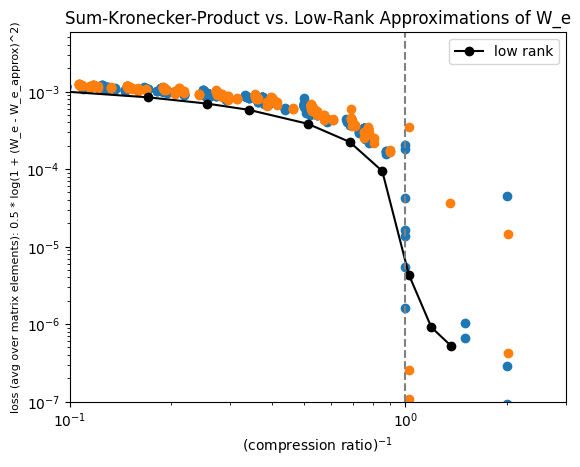

In [11]:
# visualize both the original and rightmult results
import re

# iterate through ../saved_data directory
for file in os.listdir("../saved_data"):
    pattern = r'layer7_resid_post_mlp_v5_32k_encoder_sum_kronecker_\d+x\d+_\d+x\d+_results\.pkl$'
    if re.match(pattern, file):
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o', color='C0') # label=f"{d1}x{d2} {d3}x{d4}")
            except:
                pass

for file in os.listdir("../saved_data"):
    pattern = r'layer7_resid_post_mlp_v5_32k_encoder_sum_kronecker_\d+x\d+_\d+x\d+_rightmult_results\.pkl$'
    if re.match(pattern, file):
        with open(f"../saved_data/{file}", "rb") as f:
            data = pickle.load(f)
            try:
                d1 = data['d1']
                d2 = data['d2']
                d3 = data['d3']
                d4 = data['d4']
                rs = sorted(data['losses'].keys())
                parameters = [data['parameters'][r] for r in rs]
                ratios = [p / W_e.numel() for p in parameters]
                losses = [min(data['losses'][r]) for r in rs]
                plt.plot(ratios, losses, 'o', color='C1') # label=f"{d1}x{d2} {d3}x{d4}")
            except:
                pass

# plot the low-rank frontier too
low_rank_ratios = [low_rank_encoder_parameters[r] / W_e.numel() for r in ranks]
low_rank_losses = [min(low_rank_encoder_dynamics[r]) for r in ranks]
plt.plot(low_rank_ratios, low_rank_losses, 'o-', label='low rank', color='black')

# vertical line
plt.axvline(x=1, color='grey', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-7, None)
plt.xlim(1e-1, 3e0)
plt.xlabel(r"$(\text{compression ratio})^{-1}$")
plt.ylabel("loss (avg over matrix elements): 0.5 * log(1 + (W_e - W_e_approx)^2)", fontsize=8)
plt.legend()
plt.title("Sum-Kronecker-Product vs. Low-Rank Approximations of W_e")

In [32]:
r = 32
d1, d2, d3, d4 = 512, 256, 64, 3
assert d1 * d3 == W_e.shape[0]
assert d2 * d4 == W_e.shape[1]
W1 = torch.randn(r, d1, d2, device=device, dtype=dtype)
W2 = torch.randn(r, d3, d4, device=device, dtype=dtype)
# right-multiplication matrix, initialized to be identity
# U = torch.eye(d2 * d4, device=device, dtype=dtype)
s = (var_W_e / r) ** 0.25
W1 *= s
W2 *= s

In [33]:
W = sum_kronecker_mmm(W1, W2)

In [34]:
W.var()

tensor(0.0029, device='cuda:0')

In [35]:
W_e.var()

tensor(0.0028, device='cuda:0')

In [36]:
W.shape

torch.Size([32768, 768])

In [ ]:
# each entry in W @ U is a sum of W_e.shape[1] terms, each which is a product of two terms.
# we want the variance of this sum to be equal to W_e_var. So:
# W_e_var = W_e.shape[1] * W.var() * U.var(). If we've correctly set
# W.var() = W_e_var(), then this simplifies, leaving us with 
# U.var() = 1 / W_e.shape[1]. So we should multipl

In [33]:
data['parameters']

{4: 1573120,
 8: 3146240,
 12: 4719360,
 16: 6292480,
 24: 9438720,
 32: 12584960,
 48: 18877440,
 64: 25169920,
 96: 37754880,
 128: 50339840,
 192: 75509760,
 256: 100679680,
 384: 151019520,
 512: 201359360,
 768: 302039040}

In [27]:
data['losses']

[]